# TensorFlow Lite Demo Notebook

Dieses Notebook demonstriert, wie man einfach ein Python Notebook TensorFlow Lite aufsetzt. Es beinhaltet:
- Installation der notwendigen Pakete
- Laden eines TFLite-Modells (MobileNetV2)
- Demo mit einem zufälligen Bild aus dem Internet

### Imports der notwendigen Pakete

In [5]:
# ---- Imports ----
import os
import io
import urllib.request
import numpy as np
import tensorflow as tf
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

from ipywidgets import FileUpload, VBox
from IPython.display import display

print("Imports complete.")


# ---- Paths ----
MODEL_PATH = "mobilenet_v2_1.0_224.tflite"
LABELS_PATH = "ImageNetLabels.txt"

MODEL_URL  = "https://storage.googleapis.com/download.tensorflow.org/models/tflite_11_05_08/mobilenet_v2_1.0_224.tflite"
LABELS_URL = "https://storage.googleapis.com/download.tensorflow.org/data/ImageNetLabels.txt"

Imports complete.


### Download Funktion für Modell und Prädiktionslabels

In [6]:
# ---- Download helper ----
def download(url, dest):
    if os.path.exists(dest):
        print(f"{dest} already exists.")
        return
    print(f"Downloading {url} ...")
    urllib.request.urlretrieve(url, dest)
    print(f"Saved to {dest}")


# ---- Download assets ----
download(LABELS_URL, LABELS_PATH)
download(MODEL_URL, MODEL_PATH)

assert os.path.exists(MODEL_PATH), "Model missing"
assert os.path.exists(LABELS_PATH), "Labels missing"


# ---- Load labels ----
with open(LABELS_PATH, "r") as f:
    labels = [line.strip() for line in f.readlines()]

print(f"Loaded {len(labels)} labels.")


# ---- Load model ----
interpreter = tf.lite.Interpreter(model_path=MODEL_PATH)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Model ready.")

ImageNetLabels.txt already exists.
mobilenet_v2_1.0_224.tflite already exists.
Loaded 1001 labels.
Model ready.


### Infärenzfunktion also wie das Bild mit das KI Modell in Kontakt gebracht wird

In [3]:
# ---- Inference function (correct preprocessing) ----
def classify_image(img):
    shape = input_details[0]['shape']
    h, w = shape[1], shape[2]

    img = ImageOps.exif_transpose(img).convert("RGB").resize((h, w))

    arr = np.array(img, dtype=np.float32)

    # MobileNetV2 normalization [-1, 1]
    arr = (arr / 127.5) - 1.0

    input_data = np.expand_dims(arr, axis=0)

    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()

    output = interpreter.get_tensor(output_details[0]['index'])
    pred_idx = int(np.argmax(output))

    return img, pred_idx, labels[pred_idx]


### Test mit zufälligem Bild / oder einem Bild aus dem Internet


Running test inference...
Prediction: jean (index: 609 )


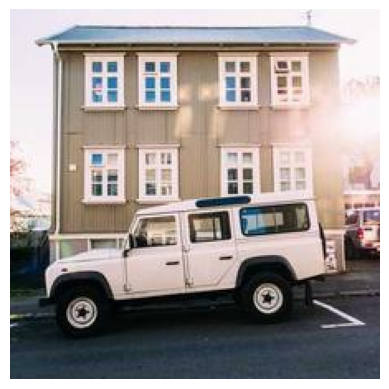

In [4]:
# ---- Test with random image ----
print("\nRunning test inference...")

url = "https://picsum.photos/224"
with urllib.request.urlopen(url) as resp:
    img = Image.open(io.BytesIO(resp.read()))

img, pred_idx, label = classify_image(img)

print("Prediction:", label, "(index:", pred_idx, ")")

plt.imshow(img)
plt.axis('off')
plt.show()